# SIP Week 7: Representation and Speaker Modeling

## Goal

In this notebook, we study how speaker-related representations are formed from speech.

We will start from simple synthetic speech signals, extract acoustic features, and analyze how representations behave in embedding space.

---

## What we will do

1. Generate simple synthetic speech-like signals
2. Extract acoustic features
3. Build utterance-level representations
4. Visualize representation space
5. Analyze similarity and robustness

---

## Key idea

A good representation should make:

- same-speaker samples close
- different-speaker samples separated
- representations robust to nuisance variation

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity

## Step 1: Generate Simple Synthetic Speech-like Signals

Instead of directly simulating embeddings, we first generate simple speech-like signals.

These are not full text-to-speech signals.
They are simplified voiced sounds with different speaker-like characteristics.

We will vary:

- fundamental frequency
- formant-like resonances
- duration
- noise level

This allows us to study representation learning from the signal level.

In [2]:
# Step 1: simple synthetic speech-like signal generator

sr = 16000

def resonator_filter(x, center_freq, bandwidth, sr=16000):
    """
    Simple second-order resonator-like filter.
    This is not a full vocal-tract model, but it creates formant-like emphasis.
    """
    r = np.exp(-np.pi * bandwidth / sr)
    theta = 2 * np.pi * center_freq / sr

    a1 = -2 * r * np.cos(theta)
    a2 = r**2

    y = np.zeros_like(x)
    for n in range(2, len(x)):
        y[n] = x[n] - a1 * y[n - 1] - a2 * y[n - 2]
    return y


def generate_speaker_signal(
    f0=120.0,
    duration=1.0,
    formants=(500, 1500, 2500),
    bandwidths=(80, 120, 160),
    noise_std=0.01,
    sr=16000
):
    """
    Generate a simple voiced speech-like signal.

    Parameters
    ----------
    f0 : float
        Fundamental frequency in Hz.
    duration : float
        Duration in seconds.
    formants : tuple
        Formant-like resonance frequencies.
    bandwidths : tuple
        Bandwidths for the resonances.
    noise_std : float
        Standard deviation of additive noise.
    sr : int
        Sampling rate.

    Returns
    -------
    x : np.ndarray
        Synthetic speech-like waveform.
    """
    t = np.arange(int(sr * duration)) / sr

    # Harmonic excitation
    x = np.zeros_like(t)
    num_harmonics = int((sr / 2) // f0)

    for k in range(1, num_harmonics + 1):
        amp = 1.0 / k
        x += amp * np.sin(2 * np.pi * k * f0 * t)

    # Apply simple amplitude envelope
    envelope = np.minimum(1.0, t / 0.05) * np.minimum(1.0, (duration - t) / 0.05)
    envelope = np.clip(envelope, 0.0, 1.0)
    x = x * envelope

    # Apply formant-like resonances
    y = x.copy()
    for cf, bw in zip(formants, bandwidths):
        y = resonator_filter(y, cf, bw, sr=sr)

    # Normalize
    y = y / (np.max(np.abs(y)) + 1e-8)

    # Add noise
    y = y + noise_std * np.random.randn(len(y))

    # Normalize again
    y = y / (np.max(np.abs(y)) + 1e-8)

    return y.astype(np.float32)

## Step 2: Define a Few Synthetic Speakers

We now define a few synthetic speakers.

Each speaker will have different:

- fundamental frequency
- formant structure
- noise level

These differences are only simplified approximations,
but they are enough to study representation and similarity.

In [3]:
# Define synthetic speakers

speaker_configs = {
    "speaker_A": {
        "f0": 120.0,
        "formants": (500, 1500, 2500),
        "bandwidths": (80, 120, 160),
        "noise_std": 0.02
    },
    "speaker_B": {
        "f0": 130.0,  
        "formants": (520, 1550, 2550),
        "bandwidths": (85, 125, 165),
        "noise_std": 0.025
    },
    "speaker_C": {
        "f0": 140.0,  
        "formants": (540, 1600, 2600),
        "bandwidths": (90, 130, 170),
        "noise_std": 0.03
    }
}
signals = {}
for name, cfg in speaker_configs.items():
    signals[name] = generate_speaker_signal(
        f0=cfg["f0"],
        duration=1.2,
        formants=cfg["formants"],
        bandwidths=cfg["bandwidths"],
        noise_std=cfg["noise_std"],
        sr=sr
    )

print("Generated speakers:", list(signals.keys()))

Generated speakers: ['speaker_A', 'speaker_B', 'speaker_C']


## Step 3: Visualize the Waveforms

Before extracting features, let us first inspect the raw waveforms.

This helps us see that different synthetic speakers already have visibly different signal patterns.

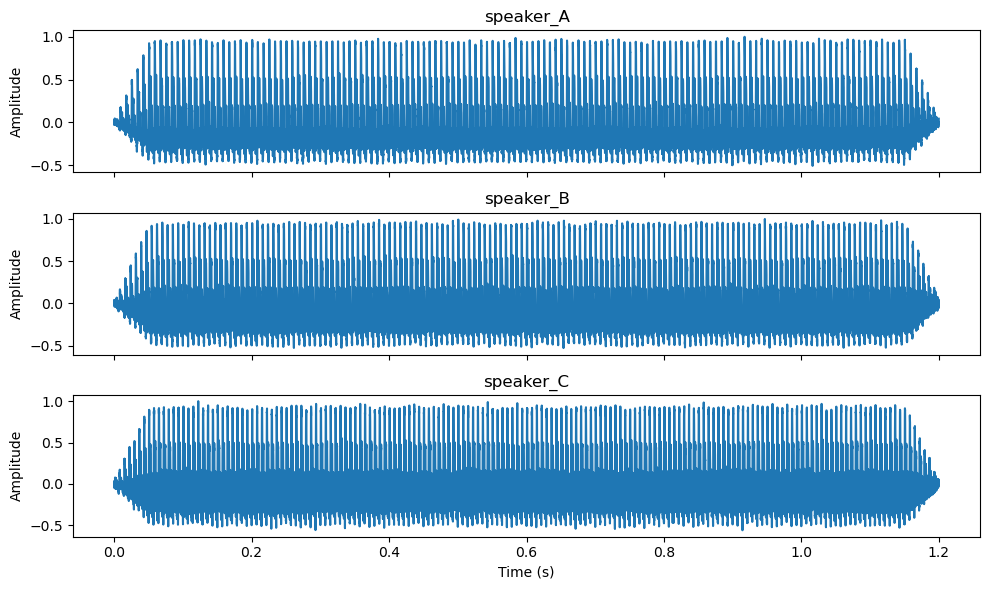

In [4]:
# Plot waveforms

fig, axes = plt.subplots(len(signals), 1, figsize=(10, 6), sharex=True)

if len(signals) == 1:
    axes = [axes]

for ax, (name, x) in zip(axes, signals.items()):
    time_axis = np.arange(len(x)) / sr
    ax.plot(time_axis, x)
    ax.set_title(name)
    ax.set_ylabel("Amplitude")

axes[-1].set_xlabel("Time (s)")
plt.tight_layout()
plt.show()

## Step 4: Listen to the Synthetic Speakers

Now let us listen to the generated signals.

Even though these are simplified signals, you should hear differences such as:

- pitch (fundamental frequency)
- timbre (formant structure)
- slight noise differences

This corresponds to speaker variability.

In [5]:
from IPython.display import Audio, display

# Listen to each speaker
for name, x in signals.items():
    print(f"Playing: {name}")
    display(Audio(x, rate=sr))

Playing: speaker_A


Playing: speaker_B


Playing: speaker_C


## Step 5: Extract Log-Mel Spectrograms

In Week 5 and Week 6, we discussed acoustic features such as log-Mel spectrograms.

Here we compute log-Mel features from the synthetic speech signals.

Why do we use log-Mel?

- it gives a compact time-frequency representation
- it approximates perceptually meaningful frequency resolution
- it is commonly used as input to modern speech systems

Our next goal is to see whether different synthetic speakers show different feature patterns.

In [6]:
# Extract log-Mel spectrograms

def compute_logmel(x, sr=16000, n_fft=512, hop_length=160, n_mels=40):
    """
    Compute log-Mel spectrogram.
    """
    mel = librosa.feature.melspectrogram(
        y=x,
        sr=sr,
        n_fft=n_fft,
        hop_length=hop_length,
        n_mels=n_mels,
        power=2.0
    )
    logmel = np.log(mel + 1e-6)
    return logmel

logmels = {}
for name, x in signals.items():
    logmels[name] = compute_logmel(x, sr=sr)

for name, feat in logmels.items():
    print(name, feat.shape)

speaker_A (40, 121)
speaker_B (40, 121)
speaker_C (40, 121)


## Step 6: Visualize Log-Mel Spectrograms

Let us now visualize the log-Mel spectrograms.

We will compare the patterns across synthetic speakers.

Things to look for:

- overall energy distribution
- harmonic structure
- differences in spectral emphasis
- smoothness or roughness caused by noise

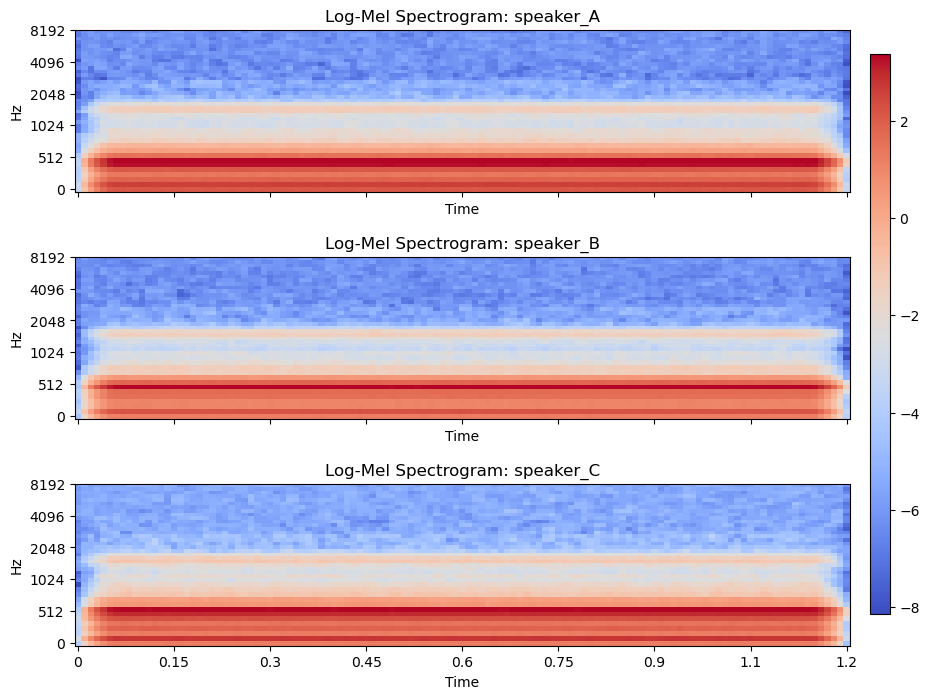

In [7]:
# Plot log-Mel spectrograms

fig, axes = plt.subplots(len(logmels), 1, figsize=(10, 8), sharex=True)

if len(logmels) == 1:
    axes = [axes]

for ax, (name, feat) in zip(axes, logmels.items()):
    img = librosa.display.specshow(
        feat,
        sr=sr,
        hop_length=160,
        x_axis='time',
        y_axis='mel',
        ax=ax
    )
    ax.set_title(f"Log-Mel Spectrogram: {name}")
    
plt.subplots_adjust(hspace=0.4)
fig.subplots_adjust(right=0.9)
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
fig.colorbar(img, cax=cbar_ax)
plt.show()

## Observation

At this stage, we are still looking at signal-level features, not embeddings.

However, we can already observe that different synthetic speakers produce different acoustic patterns.

This motivates the next question:

How can we summarize these time-varying features into a compact utterance-level representation?

## Step 7: From Time-Varying Features to Utterance-Level Representation

A log-Mel spectrogram is a time-varying feature sequence.

However, for speaker modeling, we often want a fixed-dimensional representation for the entire utterance.

A simple way is statistical pooling:

- mean over time
- standard deviation over time

This follows the idea of x-vector style utterance-level representation.

In [8]:
# Statistical pooling: mean and standard deviation over time

def statistical_pooling(feature_matrix):
    """
    feature_matrix: shape (feature_dim, time_frames)

    Returns
    -------
    pooled : np.ndarray
        Concatenation of mean and std over time
    """
    mu = np.mean(feature_matrix, axis=1)
    sigma = np.std(feature_matrix, axis=1)
    pooled = np.concatenate([mu, sigma], axis=0)
    return pooled

utterance_representations = {}
for name, feat in logmels.items():
    utterance_representations[name] = statistical_pooling(feat)

for name, rep in utterance_representations.items():
    print(name, rep.shape)

speaker_A (80,)
speaker_B (80,)
speaker_C (80,)


## Step 8: Inspect Utterance-Level Representations

Now each utterance is represented by a single vector.

This is a very simple embedding-like representation.

It is not a deep speaker embedding yet, but it already illustrates an important idea:

- frame-level features vary over time
- pooling converts them into a stable utterance-level representation

In [9]:
# Show a few dimensions of each utterance-level representation

for name, rep in utterance_representations.items():
    print(f"{name}:")
    print(rep[:10])
    print()

speaker_A:
[ 1.8490673   2.3160982   1.5813155   1.1310723   1.8027251   2.9763901
  3.063054    1.2503704  -0.00883412 -0.6503502 ]

speaker_B:
[ 1.4594692   2.425883    1.2926404   1.2850363   1.8130789   1.910449
  3.5552504   2.0355763   0.77469116 -1.1527486 ]

speaker_C:
[1.0528586  2.5840454  1.0792699  1.6951091  1.3094964  2.0953228
 2.7634501  3.1468167  0.37246096 0.13154952]



## Step 9: Generate Multiple Utterances per Speaker

To visualize embedding structure, we need multiple samples per speaker.

We generate several utterances with small variations:

- duration
- noise level

---

### Important Note: What is a "Speaker"?

A speaker is not a single utterance.

Instead, a speaker corresponds to a distribution of possible utterances.

In this notebook, we simulate this by generating multiple signals from the same speaker configuration.

This allows us to study:

- intra-speaker variability
- inter-speaker differences

In [13]:
# Generate multiple utterances per speaker

num_utterances = 20

multi_embeddings = []
multi_labels = []

speaker_variation = {
    0: {"f0_jitter": 3.0, "formant_jitter": 20.0},
    1: {"f0_jitter": 6.0, "formant_jitter": 35.0},
    2: {"f0_jitter": 4.0, "formant_jitter": 25.0},
}

for speaker_id, (name, cfg) in enumerate(speaker_configs.items()):
    for i in range(num_utterances):
        jit = speaker_variation[speaker_id]

        formants = tuple(
            f + np.random.randn() * jit["formant_jitter"]
            for f in cfg["formants"]
        )

        x = generate_speaker_signal(
            f0=cfg["f0"] + np.random.randn() * jit["f0_jitter"],
            duration=1.0 + 0.15 * np.random.randn(),
            formants=formants,
            bandwidths=cfg["bandwidths"],
            noise_std=max(0.005, cfg["noise_std"] * (1 + 0.3 * np.random.randn())),
            sr=sr
        )

        feat = compute_logmel(x, sr=sr)
        rep = statistical_pooling(feat)

        multi_embeddings.append(rep)
        multi_labels.append(speaker_id)

multi_embeddings = np.vstack(multi_embeddings)
multi_labels = np.array(multi_labels)

print("Embeddings shape:", multi_embeddings.shape)

Embeddings shape: (60, 80)


## Step 10: PCA Visualization (Task 1)

We now visualize the embedding space.

PCA projects high-dimensional embeddings into 2D.

It preserves global structure (variance).

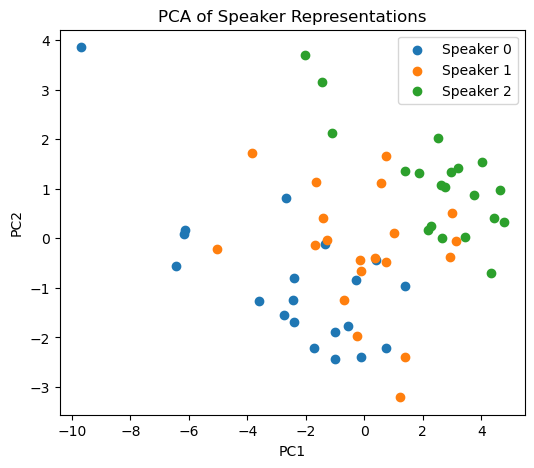

In [14]:
# PCA visualization

pca = PCA(n_components=2)
emb_pca = pca.fit_transform(multi_embeddings)

plt.figure(figsize=(6, 5))

for i in np.unique(multi_labels):
    plt.scatter(
        emb_pca[multi_labels == i, 0],
        emb_pca[multi_labels == i, 1],
        label=f"Speaker {i}"
    )

plt.title("PCA of Speaker Representations")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.show()

## Step 11: t-SNE Visualization

PCA shows global structure.

Now we use t-SNE to visualize local structure.

t-SNE emphasizes neighborhood relationships and often reveals clusters more clearly.

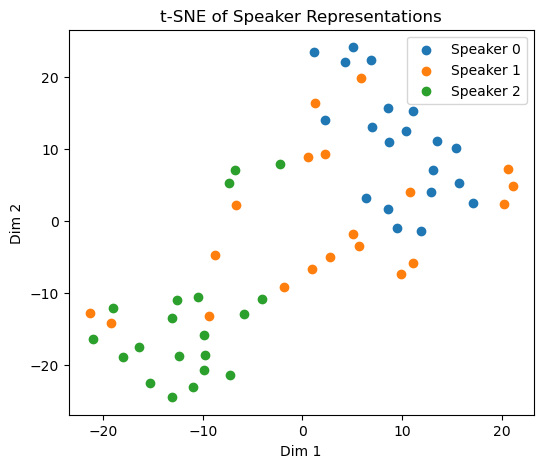

In [15]:
# t-SNE visualization

tsne = TSNE(n_components=2, random_state=0, perplexity=10)
emb_tsne = tsne.fit_transform(multi_embeddings)

plt.figure(figsize=(6, 5))

for i in np.unique(multi_labels):
    plt.scatter(
        emb_tsne[multi_labels == i, 0],
        emb_tsne[multi_labels == i, 1],
        label=f"Speaker {i}"
    )

plt.title("t-SNE of Speaker Representations")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.legend()
plt.show()

## Step 12: Observation (Task 1)

Look at the plots:

- Do samples from the same speaker tend to form clusters?
- Are different speakers reasonably separated?

Observation:

- Same-speaker samples are often close, but not identical
- Different speakers are generally separated, but may overlap

Interpretation:

- Good representations create clustering structure
- Overlap indicates potential classification errors

Important:

- Perfect separation is rare in practice
- Real embeddings often show partial overlap

This reflects the lecture idea:

d_same < d_diff, but distributions may overlap

## Step 13: When Does Similarity Fail? (Task 2)

From the lecture:

- same speaker → small distance
- different speaker → larger distance

But this is not always true.

We now test:

- When does similarity fail?
- How robust are the representations?

We analyze this using distance distributions.

In [16]:
# Compute pairwise distances

d_same = []
d_diff = []

N = len(multi_embeddings)

for i in range(N):
    for j in range(i + 1, N):
        d = np.linalg.norm(multi_embeddings[i] - multi_embeddings[j])
        
        if multi_labels[i] == multi_labels[j]:
            d_same.append(d)
        else:
            d_diff.append(d)

d_same = np.array(d_same)
d_diff = np.array(d_diff)

print("Same pairs:", len(d_same))
print("Different pairs:", len(d_diff))

Same pairs: 570
Different pairs: 1200


## Step 14: Distance Distributions

We now visualize:

- p(d | same)
- p(d | different)

This corresponds to the statistical view of representation.

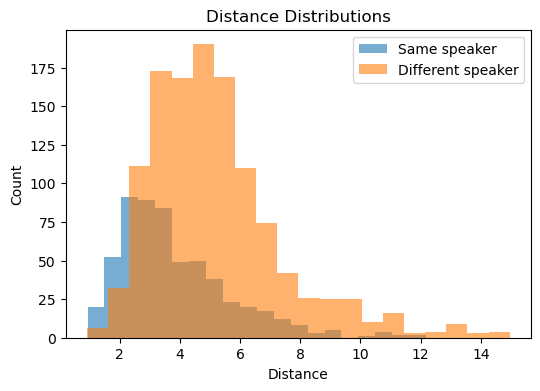

In [17]:
# Plot distance distributions

plt.figure(figsize=(6, 4))

plt.hist(d_same, bins=20, alpha=0.6, label="Same speaker")
plt.hist(d_diff, bins=20, alpha=0.6, label="Different speaker")

plt.xlabel("Distance")
plt.ylabel("Count")
plt.title("Distance Distributions")
plt.legend()

plt.show()

## Step 15: Observation

Look at the distributions:

- Same-speaker distances are generally smaller
- Different-speaker distances are larger

However:

- There is overlap between the two distributions

Interpretation:

- Overlap corresponds to potential classification errors
- Perfect separation is not achievable in practice

This reflects the key idea:

d_same < d_diff, but distributions overlap

## Step 16: Quantify Separation

We compute a simple metric:

Δ = E[d_diff] − E[d_same]

Larger Δ indicates better separation.

In [19]:
# Separation gap

delta = np.mean(d_diff) - np.mean(d_same)

print("Mean same distance:", np.mean(d_same))
print("Mean diff distance:", np.mean(d_diff))
print("Separation gap Δ:", delta)

Mean same distance: 3.8553746
Mean diff distance: 5.1955175
Separation gap Δ: 1.340143


## Step 17: Embedding Space Analysis (Task 3)

In the previous steps:

- Task 1: we visualized embeddings
- Task 2: we analyzed distance distributions

Now we analyze the structure of the embedding space.

Key questions:

- How are embeddings organized?
- What determines clustering?
- How does structure relate to performance?

## Step 18: Cluster Structure

From PCA and t-SNE:

- samples from the same speaker tend to form clusters
- different speakers are separated in space

However:

- clusters are not perfectly separated
- boundaries are not sharp

Interpretation:

- representation creates geometric structure
- but not perfect separability

## Step 19: Intra-class vs Inter-class Structure

We relate this to distance distributions:

- intra-class (same speaker):
  → small distances
  → compact clusters

- inter-class (different speakers):
  → larger distances
  → separated clusters

But:

- overlap between distributions
  → cluster overlap in visualization

## Step 20: Geometry and Representation Quality

We now connect geometry and performance:

Good representation:

- tight clusters (low intra-class variance)
- well separated clusters (high inter-class distance)

Poor representation:

- scattered clusters
- overlapping regions

Key idea:

Representation quality = geometric structure of embedding space

## Step 21: Clean vs Noisy (Conceptual)

Even without additional experiments, we can interpret:

- noise increases intra-class variance
- clusters become less compact
- overlap increases

Effect:

- distances become less reliable
- classification errors increase

This connects to robustness discussed in the lecture.

## Step 22: Final Insight

We summarize all tasks:

Task 1:
→ visualize structure

Task 2:
→ quantify distances

Task 3:
→ interpret geometry

Final understanding:

- embeddings define a geometric space
- distances define decisions
- structure determines performance

Key idea:

A good representation is one where distance becomes meaningful.